## Функции активации

### 1. Сигмойда и Гиперболический тангенс

Набор наиболее используемых функций доступен в ветке:

```
torch.nn.functional
```

Одними из первых стали применять функции сигмоиды:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}.
$$

И гиперболического тангенса:

$$
\sigma(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}.
$$

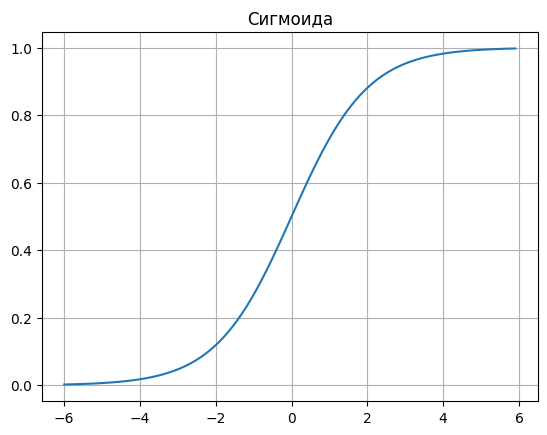

In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

x = torch.arange(-6.0, 6.0, 0.1)
y = F.sigmoid(x)

plt.plot(x.numpy(), y.numpy())
plt.title('Сигмоида')
plt.grid(True)
plt.show()

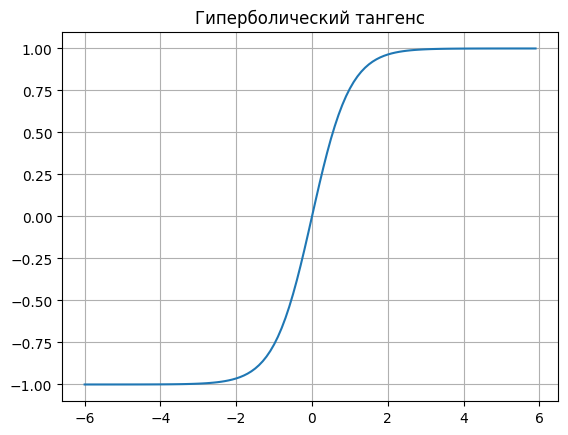

In [5]:
y = F.tanh(x)

plt.plot(x.numpy(), y.numpy())
plt.title('Гиперболический тангенс')
plt.grid(True)
plt.show()

Они очень похожи между собой с одним кардинальным различием, что сигмоида отображает выходные значения в диапазон [0; 1], а гиперболический тангенс – в диапазон [-1; 1].

Обе имеют пологие участки (насыщение), где производные близки к нулю. Поэтому глубокие сети (10+ слоёв) с ними обучаются плохо — градиенты затухают.

### 2. ReLU

Последнее время для нейронов скрытых слоев стали применять следующие функции активации:

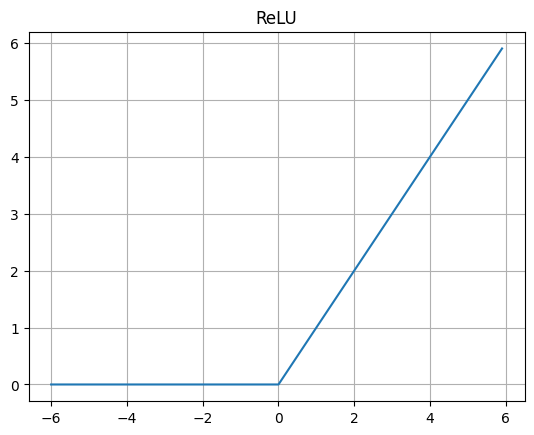

In [6]:
y = F.relu(x)

plt.plot(x.numpy(), y.numpy())
plt.title('ReLU')
plt.grid(True)
plt.show()

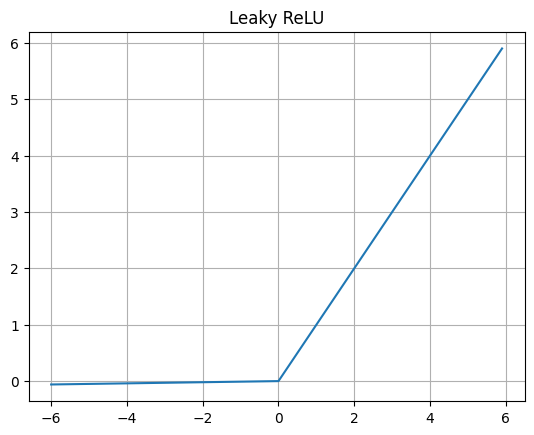

In [7]:
y = F.leaky_relu(x)

plt.plot(x.numpy(), y.numpy())
plt.title('Leaky ReLU')
plt.grid(True)
plt.show()

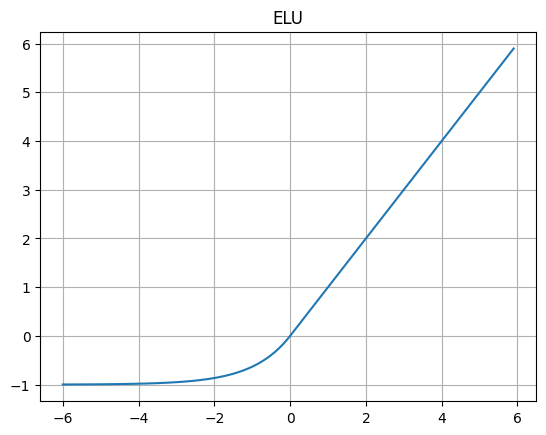

In [8]:
y = F.elu(x)

plt.plot(x.numpy(), y.numpy())
plt.title('ELU')
plt.grid(True)
plt.show()

Из них самая используемая – это ReLU (Rectified Linear Unit). Особенность всех этих трех функций в том, что они не имеют пологих участков в положительной области. Благодаря этому производные не обнуляются и процесс обучения глубоких НС протекает гораздо быстрее.

Конечно, глядя на график функции ReLU, возникает вопрос в наличии пологого участка, где производная равна нулю. Разве он не сказывается негативно на процессе обучения? Как показала практика, нет, т.к. входная сумма на каждом нейроне может произвольно увеличиваться или уменьшаться на величину bias и тем самым выводить общую сумму из пологой области.

### 3. Функции для выходного слоя

На выходном слое НС применяются разные функции активации в зависимости от решаемых задач. Они имеют некоторый наклон в отрицательной области, как раз для избегания нулевых значений производных. Но это не часто дает заметный прирост скорости и точности обучения НС, а потому они реже используются на практике.

1. Линейная для регрессии:

$$
\sigma(x) = x
$$

Функция linear обычно используется в задачах регрессии, когда выходное значение на нейроне никак не нужно изменять.Эту функцию активации имеет смысл применять только на нейронах выходного слоя, так как нейрон становится линейным. А композиция линейных моделей (нейронов) может быть описана одной эквивалентной моделью. Поэтому все скрытые слои НС с такой функцией активации могут быть заменены одним единственным нейроном.

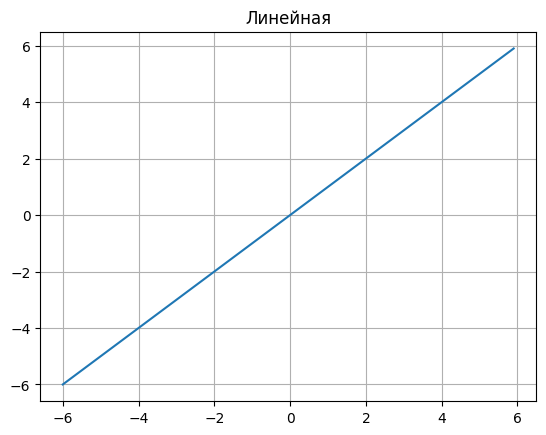

In [13]:
y = x

plt.plot(x.numpy(), y.numpy())
plt.title('Линейная')
plt.grid(True)
plt.show()

2. Сигмойда для бинарной классификации:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}.
$$

Сигмоидная функция активации часто применяется для формирования выходного значения в задачах бинарной классификации. Ее значения [0; 1] могут быть интерпретированы, как «уверенность» сети в том или ином прогнозе.

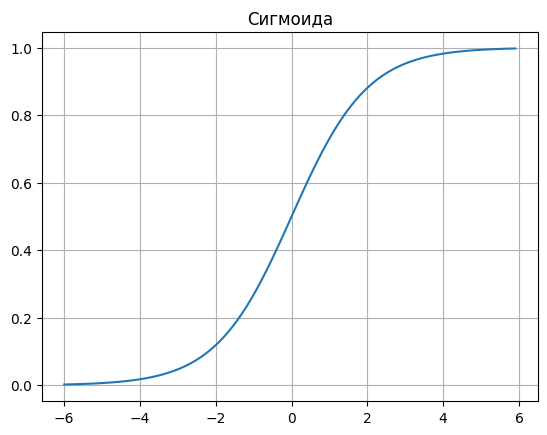

In [14]:
y = F.sigmoid(x)

plt.plot(x.numpy(), y.numpy())
plt.title('Сигмоида')
plt.grid(True)
plt.show()

3. Софтмакс для многоклассовой классификации:

$$
\sigma(x_i) = \frac{\exp(x_i)}{\sum_{j=1}^{M} \exp(x_j)}
$$

Последняя функция активации SoftMax применяется в задачах многоклассовой классификации. Она тоже для каждого выхода дает значения в диапазоне [0; 1], а сумма всех выходов всегда равна 1. То есть, их можно интерпретировать в некотором смысле, как вероятности определения того или иного класса.

C:\Users\Evgen\AppData\Local\Temp\ipykernel_6424\2876774137.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  y = F.softmax(x)


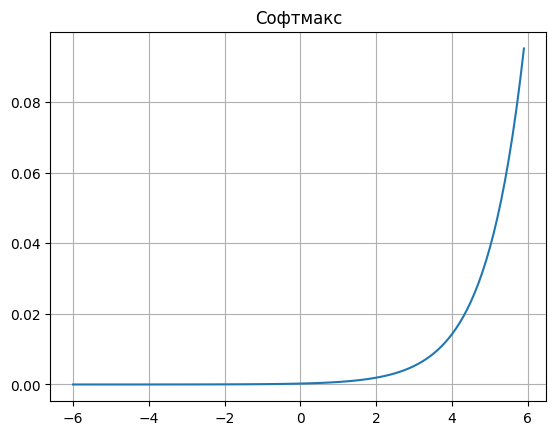

In [16]:
y = F.softmax(x)

plt.plot(x.numpy(), y.numpy())
plt.title('Софтмакс')
plt.grid(True)
plt.show()

Последняя функция активации SoftMax применяется в задачах многоклассовой классификации. Она тоже для каждого выхода дает значения в диапазоне [0; 1], а сумма всех выходов всегда равна 1. То есть, их можно интерпретировать в некотором смысле, как вероятности определения того или иного класса.